In [4]:
import os
# Force clear the environment variable to let PyTorch auto-detect
if 'CUDA_VISIBLE_DEVICES' in os.environ:
    del os.environ['CUDA_VISIBLE_DEVICES']

import torch
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"Device Count: {torch.cuda.device_count()}")


CUDA Available: True
Device Count: 1


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import ultralytics
import cv2
from ultralytics import YOLO

# Check installation and version
ultralytics.checks()


Ultralytics 8.4.21  Python-3.12.6 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
Setup complete  (16 CPUs, 23.3 GB RAM, 94.0/952.8 GB disk)


In [ ]:
# load train, validation, and test data
data_config = 'VisDrone.yaml'


In [ ]:
# Load a pretrained YOLO26 model
model = YOLO("yolo26n.pt") 

# Start training
results = model.train(
    data=data_config,
    epochs=10,                          # Set epochs based on your requirement
    device=0,
    imgsz=640,                          # Image resolution
    batch=8,                            
    name='yolo26_visdrone_baseline',
    plots=True                          # Generates the loss curves required for Part II
)


Ultralytics 8.4.21  Python-3.12.6 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=VisDrone.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26_visdrone_baseline3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

Plot successfully generated and saved as 'training_validation_metrics.png'


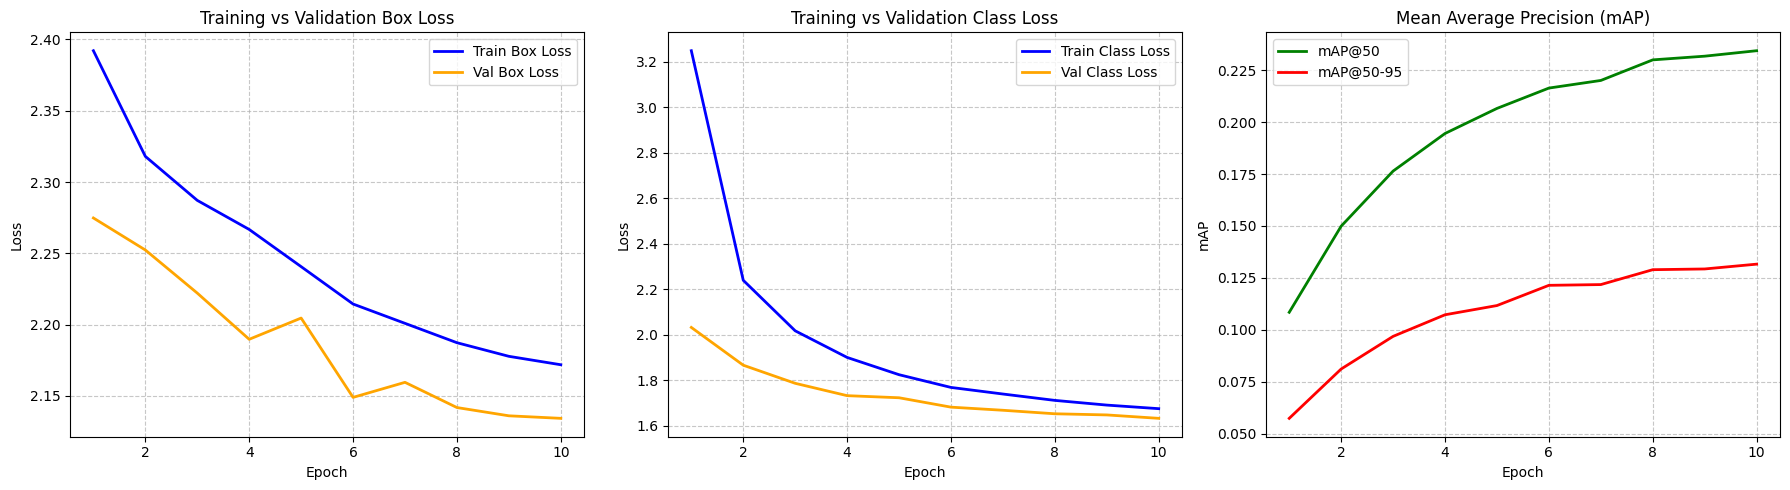

In [ ]:
# Load the results.csv file
df = pd.read_csv('results.csv')

# YOLO result column names often have leading spaces, so we strip them
df.columns = df.columns.str.strip()

# Create a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Plot Box Loss (Training vs Validation)
axes[0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', color='blue', linewidth=2)
axes[0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', color='orange', linewidth=2)
axes[0].set_title('Training vs Validation Box Loss', fontsize=12)
axes[0].set_xlabel('Epoch', fontsize=10)
axes[0].set_ylabel('Loss', fontsize=10)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# 2. Plot Class Loss (Training vs Validation)
axes[1].plot(df['epoch'], df['train/cls_loss'], label='Train Class Loss', color='blue', linewidth=2)
axes[1].plot(df['epoch'], df['val/cls_loss'], label='Val Class Loss', color='orange', linewidth=2)
axes[1].set_title('Training vs Validation Class Loss', fontsize=12)
axes[1].set_xlabel('Epoch', fontsize=10)
axes[1].set_ylabel('Loss', fontsize=10)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

# 3. Plot Mean Average Precision (mAP)
axes[2].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='green', linewidth=2)
axes[2].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color='red', linewidth=2)
axes[2].set_title('Mean Average Precision (mAP)', fontsize=12)
axes[2].set_xlabel('Epoch', fontsize=10)
axes[2].set_ylabel('mAP', fontsize=10)
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent overlap and save the figure
plt.tight_layout()


In [ ]:
# Load your trained model weights
model = YOLO('runs/detect/train/weights/best.pt')

# Run validation on your dataset
metrics = model.val() 

print(f"Overall Precision: {metrics.results_dict['metrics/precision(B)']}")
print(f"Overall Recall: {metrics.results_dict['metrics/recall(B)']}")
print(f"mAP@50: {metrics.results_dict['metrics/mAP50(B)']}")


Ultralytics 8.4.21  Python-3.12.6 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 122 layers, 2,408,932 parameters, 0 gradients, 5.4 GFLOPs
val: Fast image access  (ping: 0.20.0 ms, read: 4.92.4 MB/s, size: 54.0 KB)
val: Scanning D:\Uni\Year4\CMPE_401\YOLOProject\datasets\coco8\labels\val.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.3s/it 2.3s
                   all          4         17      0.906      0.646      0.888      0.702
                person          3         10          1      0.376      0.804       0.42
                   dog          1          1      0.795          1      0.995      0.895
                 horse          1          2       0.86          1      0.995      0.798
              elephant          1          2      0.782        0.5      0.543      0.309
              umbr

In [ ]:
print("Variable: imgsz = 1024 (Control was 640)")

# Load the raw, pre-trained nano weights (same starting point as baseline)
model = YOLO('yolo26n.pt')

# Train the model with the experimental variable
results = model.train(
    data='VisDrone.yaml',         
    epochs=10,                    # Variable kept at 10
    device=0,
    imgsz=1024,                   # Variable for experiment: Increased from 640
    batch=8,                      
    name='exp_resolution_1024',   # Organizes output cleanly
    project='runs/detect'                    
)


Variable: imgsz = 1024 (Control was 640)
New https://pypi.org/project/ultralytics/8.4.33 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.21  Python-3.12.6 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=VisDrone.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mos

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000002395D4267A0>
Traceback (most recent call last):
  File "d:\Uni\Year4\CMPE_401\YOLOProject\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "d:\Uni\Year4\CMPE_401\YOLOProject\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1665, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
                                   ^^^^^^^^^^^^^^^^^^^^
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000002395D4267A0>
Traceback (most recent call last):
  File "d:\Uni\Year4\CMPE_401\YOLOProject\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "d:\Uni\Year4\CMPE_401\YOLOProject\.venv\Lib\site-packages\torch\utils\data\dataloader.py

KeyboardInterrupt: 

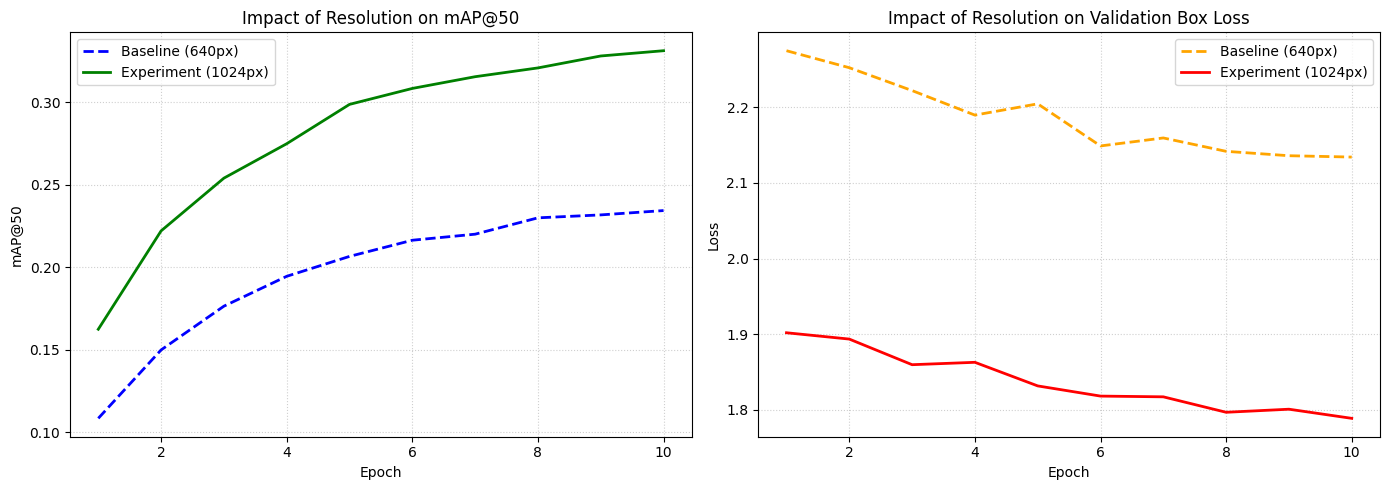

Plot saved as 'experiment_1_comparison.png'


In [ ]:
# Ensure plots render directly in the notebook
%matplotlib inline

# NOTE: Update 'train3' to the exact folder name of your best baseline run
baseline_csv_path = 'runs/detect/yolo26_visdrone_baseline3/results.csv'
experiment_csv_path = 'runs/detect/runs/detect/exp_resolution_1024/results.csv'

# Load data
df_base = pd.read_csv(baseline_csv_path)
df_exp = pd.read_csv(experiment_csv_path)

# Strip whitespace from column names
df_base.columns = df_base.columns.str.strip()
df_exp.columns = df_exp.columns.str.strip()

# Create a 1x2 grid for our comparison plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. mAP@50 Comparison Plot
axes[0].plot(df_base['epoch'], df_base['metrics/mAP50(B)'], label='Baseline (640px)', color='blue', linestyle='--', linewidth=2)
axes[0].plot(df_exp['epoch'], df_exp['metrics/mAP50(B)'], label='Experiment (1024px)', color='green', linewidth=2)
axes[0].set_title('Impact of Resolution on mAP@50', fontsize=12)
axes[0].set_xlabel('Epoch', fontsize=10)
axes[0].set_ylabel('mAP@50', fontsize=10)
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# 2. Validation Box Loss Comparison Plot
axes[1].plot(df_base['epoch'], df_base['val/box_loss'], label='Baseline (640px)', color='orange', linestyle='--', linewidth=2)
axes[1].plot(df_exp['epoch'], df_exp['val/box_loss'], label='Experiment (1024px)', color='red', linewidth=2)
axes[1].set_title('Impact of Resolution on Validation Box Loss', fontsize=12)
axes[1].set_xlabel('Epoch', fontsize=10)
axes[1].set_ylabel('Loss', fontsize=10)
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

# Adjust layout and display the plot inline
plt.tight_layout()
plt.show()


In [ ]:
# Load the raw, pre-trained nano weights (same starting point as baseline)
model = YOLO('yolo26n.pt')

# Train the model with the experimental variable
results = model.train(
    data='VisDrone.yaml',         
    epochs=10,                    # Variable kept at 10
    device=0,
    imgsz=1024,                   # Variable for experiment: Increased from 640
    batch=8,                      
    weight_decay=0.002,           # Increase L2 regularization 
    dropout=0.15,                 # Use 15% droput for generalization
    workers=2,
    name='exp_resolution_1024',   # Organizes output cleanly
    project='part4'                    
)

print("--- Improvement Cycle Completed ---")


New https://pypi.org/project/ultralytics/8.4.33 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.21  Python-3.12.6 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=VisDrone.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.15, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_resol

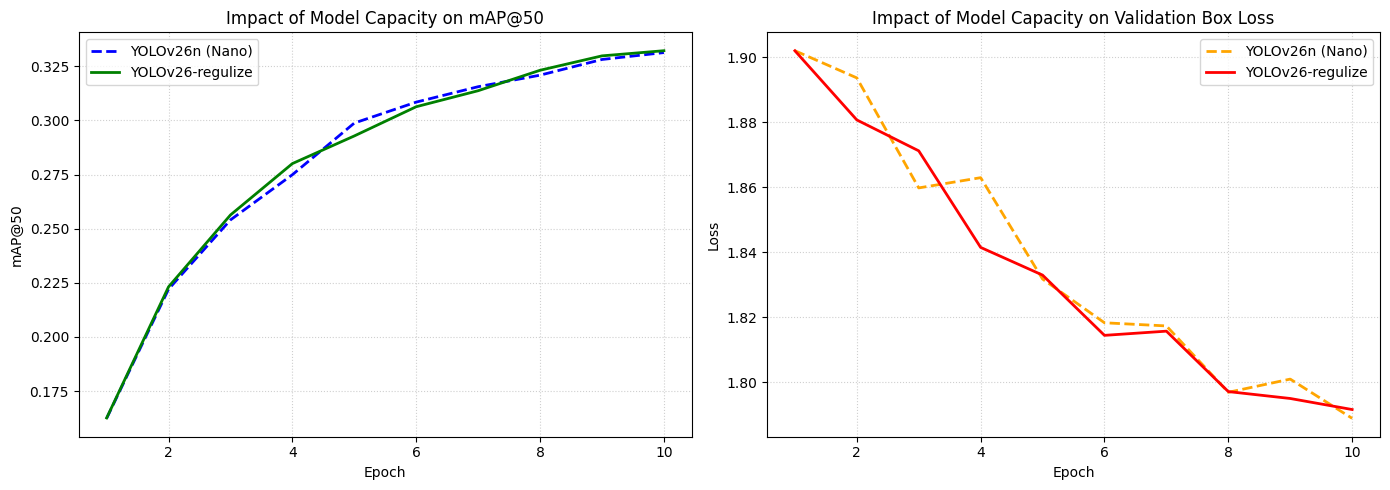

Plot saved as 'experiment_2_improvement.png'


In [ ]:
# Ensure plots render directly in the notebook
%matplotlib inline

# The baseline is now the successful run from Part III
part3_baseline_csv = 'runs/detect/runs/detect/exp_resolution_1024/results.csv'
part4_improve_csv = 'runs/detect/part4/exp_resolution_1024/results.csv'

# Load data
df_base = pd.read_csv(part3_baseline_csv)
df_improve = pd.read_csv(part4_improve_csv)

# Strip whitespace from column names
df_base.columns = df_base.columns.str.strip()
df_improve.columns = df_improve.columns.str.strip()

# Create a 1x2 grid for our comparison plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. mAP Comparison Plot
axes[0].plot(df_base['epoch'], df_base['metrics/mAP50(B)'], label='YOLOv26n (Nano)', color='blue', linestyle='--', linewidth=2)
axes[0].plot(df_improve['epoch'], df_improve['metrics/mAP50(B)'], label='YOLOv26-regulize', color='green', linewidth=2)
axes[0].set_title('Impact of Model Capacity on mAP@50', fontsize=12)
axes[0].set_xlabel('Epoch', fontsize=10)
axes[0].set_ylabel('mAP@50', fontsize=10)
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# 2. Validation Box Loss Comparison Plot
axes[1].plot(df_base['epoch'], df_base['val/box_loss'], label='YOLOv26n (Nano)', color='orange', linestyle='--', linewidth=2)
axes[1].plot(df_improve['epoch'], df_improve['val/box_loss'], label='YOLOv26-regulize', color='red', linewidth=2)
axes[1].set_title('Impact of Model Capacity on Validation Box Loss', fontsize=12)
axes[1].set_xlabel('Epoch', fontsize=10)
axes[1].set_ylabel('Loss', fontsize=10)
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

# Adjust layout and display the plot inline
plt.tight_layout()
plt.show()

# Save the figure to your directory for the README
fig.savefig('experiment_2_improvement.png', dpi=300)
print("Plot saved as 'experiment_2_improvement.png'")


In [ ]:
# Load the raw, pre-trained small weights (same starting point as baseline)
model = YOLO('yolo26s.pt')

# Train the model with the experimental variable
results = model.train(
    data='VisDrone.yaml',         
    epochs=10,                    # Variable kept at 10
    device=0,
    imgsz=1024,                   # Variable for experiment: Increased from 640
    batch=8,                      
    workers=2,
    name='exp_improve_yolo26s_1024',   # Organizes output cleanly
    project='part4s'                    
)

print("--- Improvement Cycle Completed ---")


New https://pypi.org/project/ultralytics/8.4.33 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.21  Python-3.12.6 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=VisDrone.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_improv

KeyboardInterrupt: 

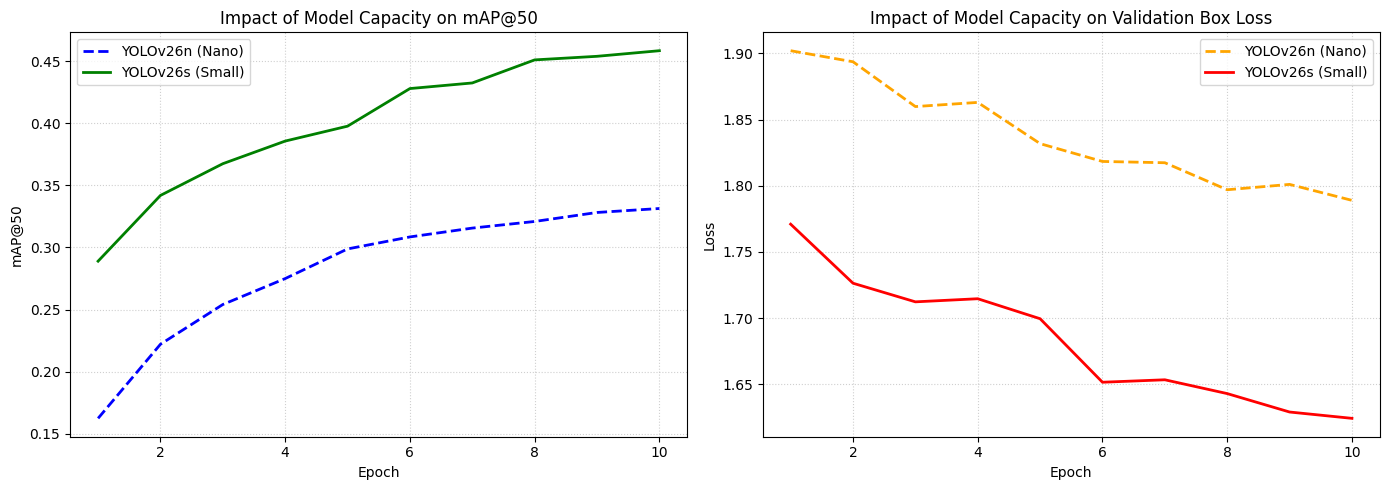

Plot saved as 'experiment_2-1_improvement.png'


In [4]:
# Ensure plots render directly in the notebook
%matplotlib inline

# The baseline is now the successful run from Part III
part3_baseline_csv = 'runs/detect/runs/detect/exp_resolution_1024/results.csv'
part4s_improve_csv = 'runs/detect/part4s/exp_improve_yolo26s_1024/results.csv'

# Load data
df_base = pd.read_csv(part3_baseline_csv)
df_improve = pd.read_csv(part4s_improve_csv)

# Strip whitespace from column names
df_base.columns = df_base.columns.str.strip()
df_improve.columns = df_improve.columns.str.strip()

# Create a 1x2 grid for our comparison plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. mAP Comparison Plot
axes[0].plot(df_base['epoch'], df_base['metrics/mAP50(B)'], label='YOLOv26n (Nano)', color='blue', linestyle='--', linewidth=2)
axes[0].plot(df_improve['epoch'], df_improve['metrics/mAP50(B)'], label='YOLOv26s (Small)', color='green', linewidth=2)
axes[0].set_title('Impact of Model Capacity on mAP@50', fontsize=12)
axes[0].set_xlabel('Epoch', fontsize=10)
axes[0].set_ylabel('mAP@50', fontsize=10)
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# 2. Validation Box Loss Comparison Plot
axes[1].plot(df_base['epoch'], df_base['val/box_loss'], label='YOLOv26n (Nano)', color='orange', linestyle='--', linewidth=2)
axes[1].plot(df_improve['epoch'], df_improve['val/box_loss'], label='YOLOv26s (Small)', color='red', linewidth=2)
axes[1].set_title('Impact of Model Capacity on Validation Box Loss', fontsize=12)
axes[1].set_xlabel('Epoch', fontsize=10)
axes[1].set_ylabel('Loss', fontsize=10)
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

# Adjust layout and display the plot inline
plt.tight_layout()
plt.show()

# Save the figure to your directory for the README
fig.savefig('experiment_2_improvement.png', dpi=300)
print("Plot saved as 'experiment_2-1_improvement.png'")


In [ ]:
# Trained on Kaggle to make use of GPU
# Competitor Architecture: YOLOv10 Small
competitor_model = YOLO('yolov10s.pt')

# Train from chosen configuration from Part IV
results = competitor_model.train(
    data='/kaggle/input/datasets/kushagrapandya/visdrone-dataset/VisDrone.yaml',
    epochs=10,
    device=0,
    imgsz=1024,            # Locked: Chosen resolution
    batch=8,               # Locked: Chosen batch size for the T4 GPU
    workers=4,             
    name='exp_part5_yolov8s_competitor',
    project='part5-10'
    plots=True
)


In [ ]:
# Trained on Kaggle to make use of GPU
# Competitor Architecture: YOLOv8 Small
competitor_model = YOLO('yolov8s.pt')

# Train from chosen configuration from Part IV
results = competitor_model.train(
    data='/kaggle/input/datasets/kushagrapandya/visdrone-dataset/VisDrone.yaml',
    epochs=10,
    device=0,
    imgsz=1024,            # Locked: Chosen resolution
    batch=8,               # Locked: Chosen batch size for the T4 GPU
    workers=4,             
    name='exp_part5_yolov8s_competitor',
    project='part5-8',
    plots=True
)


In [ ]:
# Trained on Kaggle to make use of GPU
# Competitor Architecture: YOLOv11 Small
competitor_model = YOLO('yolo11s.pt')

# Train from chosen configuration from Part IV
results = competitor_model.train(
    data='/kaggle/input/datasets/kushagrapandya/visdrone-dataset/VisDrone.yaml',
    epochs=10,
    device=0,
    imgsz=1024,            # Locked: Chosen resolution
    batch=8,               # Locked: Chosen batch size for the T4 GPU
    workers=4,             
    name='exp_part5_yolov11s_competitor',
    project='part5-11',
    plots=True
)


--- Extracting Data and Generating 3x3 Comparison Grid ---


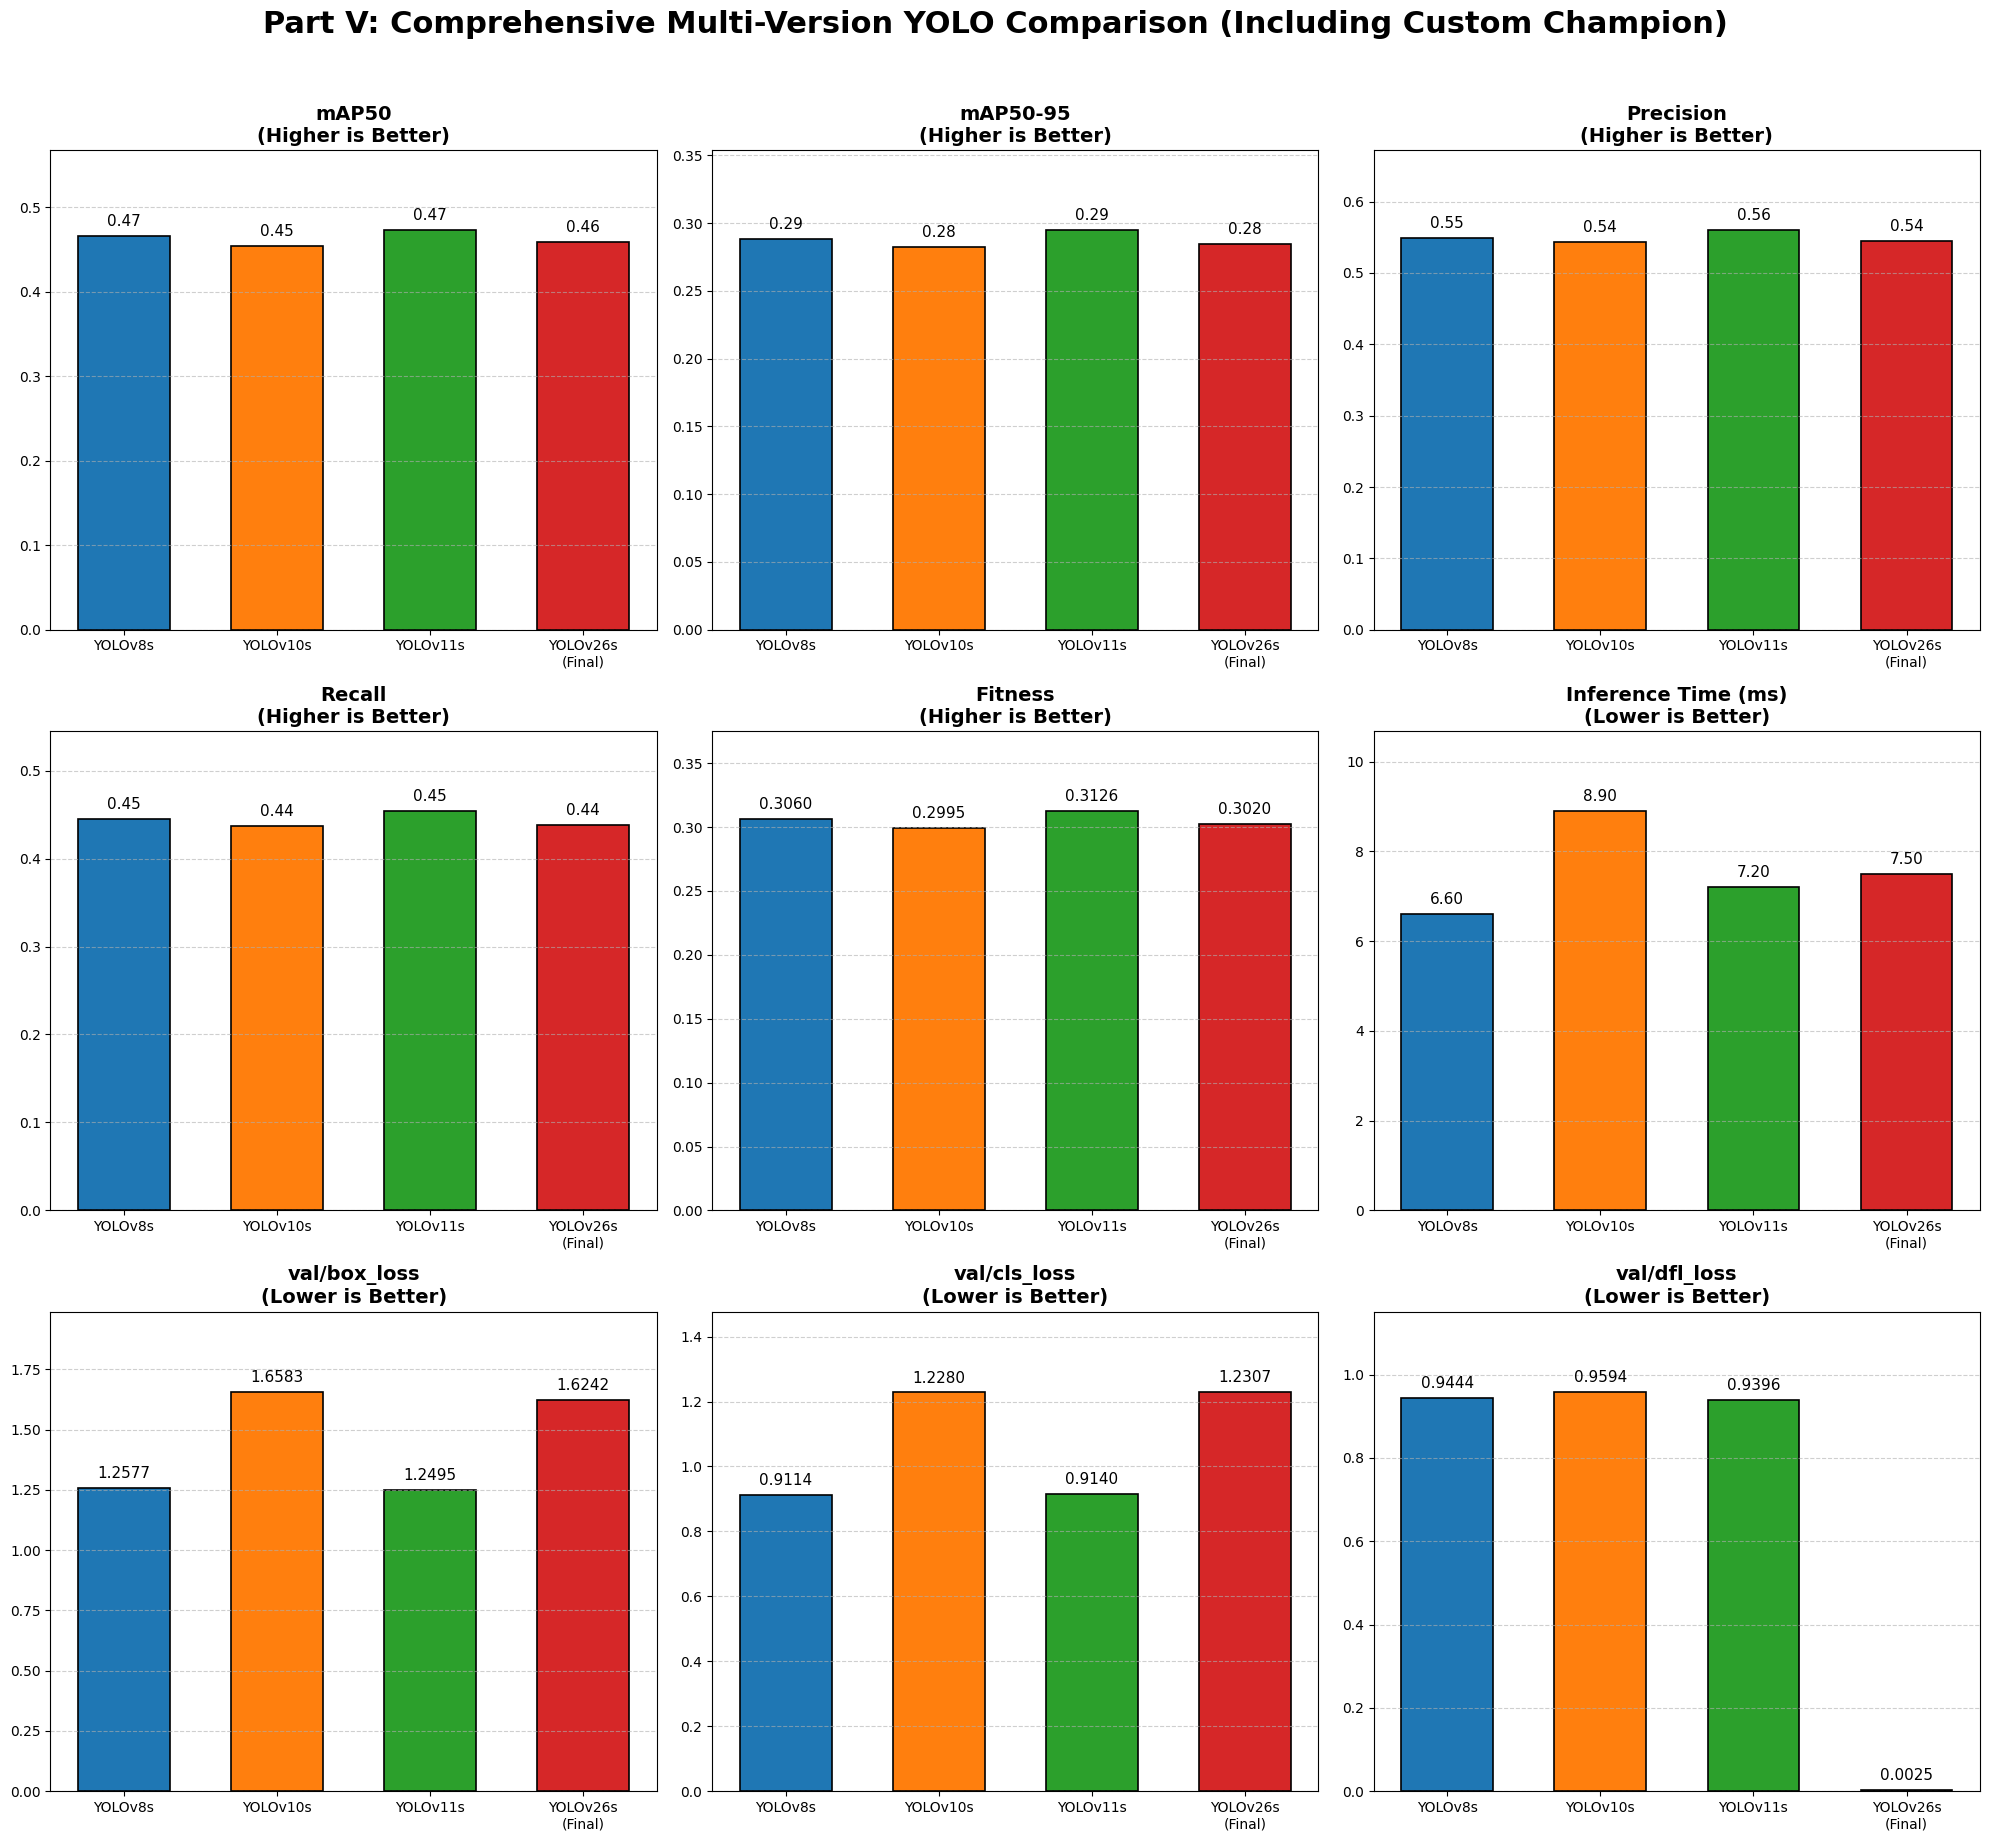


Success! Saved 4-model comparison grid as 'comprehensive_4way_yolo_comparison.png'


In [ ]:
# Ensure plots render directly in the notebook
%matplotlib inline

print("--- Extracting Data and Generating 3x3 Comparison Grid ---")

# 1. Define your exact file directories (using raw strings 'r' to handle Windows backslashes safely)
dirs = {
    'YOLOv8s': r'runs\detect\part5-8\exp_part5_yolov8s_competitor',
    'YOLOv10s': r'runs\detect\part5-10\exp_part5_yolov10s_competitor6',
    'YOLOv11s': r'runs\detect\part5-11\exp_part5_yolov11s_competitor',
    'YOLOv26s\n(Final)': r'runs\detect\part4s\exp_improve_yolo26s_1024'
}

# 2. Manual Inference Times
# Inference time isn't stored in results.csv. Check your terminal output
# (or the validation speed logs) and input the 'inference ms/im' values here:
inference_times = {
    'YOLOv8s': 6.6,  
    'YOLOv10s': 8.9, 
    'YOLOv11s': 7.2,  
    'YOLOv26s\n(Final)': 7.5  # From earlier Part 4 logs
}

data = []

# 3. Loop through the directories
for model_name, folder_path in dirs.items():
    csv_path = os.path.join(folder_path, 'results.csv')
    try:
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        
        final_epoch = df.iloc[-1]
        
        map50 = final_epoch['metrics/mAP50(B)']
        map50_95 = final_epoch['metrics/mAP50-95(B)']
        fitness = (0.1 * map50) + (0.9 * map50_95)
        
        data.append({
            'Model': model_name,
            'mAP50': map50,
            'mAP50-95': map50_95,
            'Precision': final_epoch['metrics/precision(B)'],
            'Recall': final_epoch['metrics/recall(B)'],
            'Fitness': fitness,
            'Inference Time (ms)': inference_times[model_name],
            'val/box_loss': final_epoch['val/box_loss'],
            'val/cls_loss': final_epoch['val/cls_loss'],
            'val/dfl_loss': final_epoch['val/dfl_loss']
        })
    except FileNotFoundError:
        print(f"ERROR: Could not find results.csv in {folder_path}.")

results_df = pd.DataFrame(data)

# 4. Set up the 3x3 Plotting Grid
metrics_to_plot = [
    ('mAP50', 'Higher is Better'), 
    ('mAP50-95', 'Higher is Better'), 
    ('Precision', 'Higher is Better'),
    ('Recall', 'Higher is Better'), 
    ('Fitness', 'Higher is Better'), 
    ('Inference Time (ms)', 'Lower is Better'),
    ('val/box_loss', 'Lower is Better'), 
    ('val/cls_loss', 'Lower is Better'), 
    ('val/dfl_loss', 'Lower is Better')
]

fig, axes = plt.subplots(3, 3, figsize=(20, 18)) # Slightly wider to accommodate 4 bars
fig.suptitle('Part V: Comprehensive Multi-Version YOLO Comparison (Including Custom Champion)', fontsize=22, fontweight='bold', y=1.02)

axes = axes.flatten()

# Added a 4th color (Red) to highlight your champion model
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 

# 5. Generate each subplot
for i, (metric, trend) in enumerate(metrics_to_plot):
    ax = axes[i]
    bars = ax.bar(results_df['Model'], results_df[metric], color=colors, width=0.6, edgecolor='black', linewidth=1.2)
    
    ax.set_title(f'{metric}\n({trend})', fontsize=14, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    # Auto-label the top of each bar
    for bar in bars:
        height = bar.get_height()
        label_fmt = f'{height:.4f}' if 'loss' in metric.lower() or metric == 'Fitness' else f'{height:.2f}'
        ax.annotate(label_fmt,
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11)
        
    y_max = results_df[metric].max()
    ax.set_ylim(0, y_max * 1.2) 

# Display and Export
plt.tight_layout()
plt.show()

fig.savefig('comprehensive_4way_yolo_comparison.png', dpi=300, bbox_inches='tight')
print("\nSuccess! Saved 4-model comparison grid as 'comprehensive_4way_yolo_comparison.png'")


In [9]:
print("--- Starting Official Test Set Evaluation ---")

# 1. Define paths to the 'best' weights for each trained model
# (Using raw strings 'r' for safe Windows path handling)
weight_paths = {
    'YOLOv8s': r'runs\detect\part5-8\exp_part5_yolov8s_competitor\weights\best.pt',
    'YOLOv10s': r'runs\detect\part5-10\exp_part5_yolov10s_competitor6\weights\best.pt',
    'YOLOv11s': r'runs\detect\part5-11\exp_part5_yolov11s_competitor\weights\best.pt',
    'YOLOv26s (Champion)': r'runs\detect\part4s\exp_improve_yolo26s_1024\weights\best.pt'
}

test_results = []

# 2. Loop through each model and evaluate on the Test split
for model_name, weights in weight_paths.items():
    print(f"\n=======================================================")
    print(f"Evaluating {model_name} on the completely unseen Test Set...")
    print(f"=======================================================\n")
    
    try:
        # Load the trained model
        model = YOLO(weights)
        
        # Clean up the name for folder creation
        safe_name = model_name.replace('\n', '_').replace(' ', '_').replace('(', '').replace(')', '')
        
        # Run validation explicitly on the 'test' split
        metrics = model.val(
            data='VisDrone.yaml',  # Ultralytics will look for 'test:' inside this YAML
            split='test',          # <--- CRITICAL: This forces the use of the Test Set!
            imgsz=1024,            # Keep your 1024px champion resolution
            batch=8,               # Kept low to prevent VRAM overflow during testing
            device=0,              # Use GPU
            project='runs/test',   # Save these in a separate 'test' folder, not 'detect'
            name=f'test_eval_{safe_name}'
        )
        
        # Extract metrics directly from the returned Ultralytics object
        test_results.append({
            'Model': model_name,
            'Test mAP@50 (%)': round(metrics.box.map50 * 100, 2),
            'Test mAP@50-95 (%)': round(metrics.box.map * 100, 2),
            'Test Precision (%)': round(metrics.box.mp * 100, 2),
            'Test Recall (%)': round(metrics.box.mr * 100, 2)
        })
        
    except Exception as e:
        print(f"ERROR running {model_name}: {e}")

# 3. Create and display a clean table of the final results
print("\n\n--- 🏆 FINAL TEST SET RESULTS 🏆 ---")
results_df = pd.DataFrame(test_results)

# 'display()' renders a beautiful HTML table in Jupyter Notebooks
display(results_df)

# Optional: Save this to a CSV for your records
results_df.to_csv('final_test_set_metrics.csv', index=False)


--- Starting Official Test Set Evaluation ---

Evaluating YOLOv8s on the completely unseen Test Set...

Ultralytics 8.4.21  Python-3.12.6 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
Model summary (fused): 73 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 688.9306.0 MB/s, size: 129.4 KB)
val: Scanning D:\Uni\Year4\CMPE_401\YOLOProject\datasets\VisDrone\labels\test.cache... 1610 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1610/1610  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 202/202 6.8it/s 29.9s<0.2s
                   all       1610      75102      0.477      0.398      0.384       0.23
            pedestrian       1197      21006      0.525       0.35      0.367      0.157
                people        797       6376      0.495      0.184      0.212     0.0779
               bicycle        377       1302       0.28      0.19

,Model,Test mAP@50 (%),Test mAP@50-95 (%),Test Precision (%),Test Recall (%)
0,YOLOv8s,38.44,23.01,47.71,39.83
1,YOLOv10s,38.10,22.63,47.68,39.58
2,YOLOv11s,38.75,22.90,48.81,40.12
3,YOLOv26s (Champion),38.70,23.04,47.88,40.02
